In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns 


Text(0, 0.5, 'Y label')

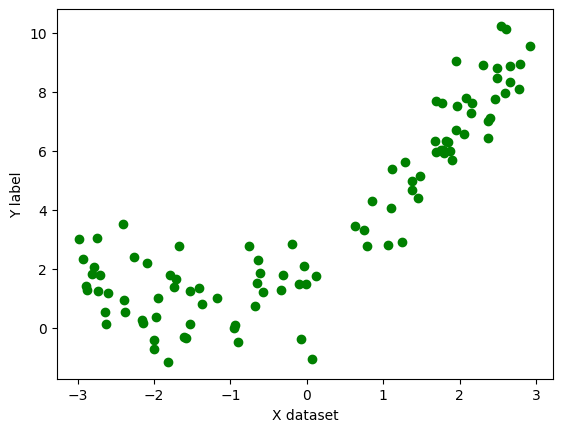

In [191]:
x=6*np.random.rand(100,1)-3
y=0.5*x**2+1.5*x+2+np.random.randn(100,1)
# quadratic eq used - 0.5x^2 + 1.5x + 2 + outliers
plt.scatter(x,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y label')

In [192]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [193]:
# Lets implement simple LR
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()


In [194]:
regression_1.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [195]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(x_test))
print(score)

0.7565308770094925


Text(0, 0.5, 'Y')

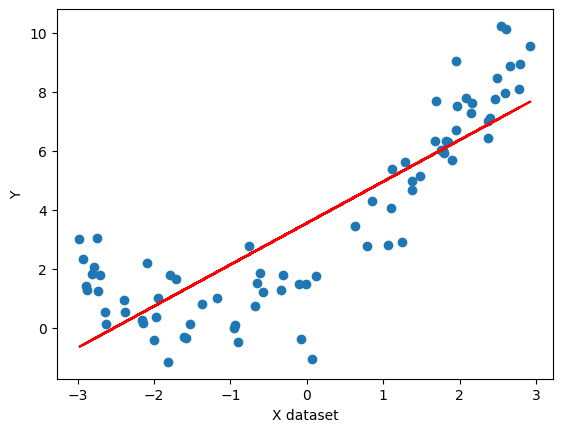

In [196]:
# Lets visualize this model
plt.plot(x_train,regression_1.predict(x_train),color='r')
plt.scatter(x_train,y_train)
plt.xlabel('X dataset')
plt.ylabel('Y')

In [197]:
 # lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures


In [198]:
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)


In [199]:
x_train_poly

array([[ 1.00000000e+00, -2.15780966e+00,  4.65614252e+00],
       [ 1.00000000e+00, -2.09082412e+00,  4.37154551e+00],
       [ 1.00000000e+00,  2.36613782e+00,  5.59860821e+00],
       [ 1.00000000e+00,  2.36324896e+00,  5.58494567e+00],
       [ 1.00000000e+00, -6.50568577e-01,  4.23239474e-01],
       [ 1.00000000e+00,  8.55357827e-01,  7.31637011e-01],
       [ 1.00000000e+00,  6.29109313e-01,  3.95778528e-01],
       [ 1.00000000e+00, -6.16137691e-01,  3.79625654e-01],
       [ 1.00000000e+00,  7.83734151e-01,  6.14239219e-01],
       [ 1.00000000e+00, -6.55079987e-03,  4.29129789e-05],
       [ 1.00000000e+00, -3.42442014e-01,  1.17266533e-01],
       [ 1.00000000e+00, -2.37952920e+00,  5.66215920e+00],
       [ 1.00000000e+00,  1.78660206e+00,  3.19194691e+00],
       [ 1.00000000e+00,  1.84963482e+00,  3.42114897e+00],
       [ 1.00000000e+00,  1.11579680e+00,  1.24500250e+00],
       [ 1.00000000e+00,  2.48722011e+00,  6.18626386e+00],
       [ 1.00000000e+00,  1.28668042e+00

In [200]:
x_test

array([[-1.67921902],
       [ 2.30927991],
       [-2.405062  ],
       [ 2.48078971],
       [ 1.76258162],
       [-0.03789596],
       [-1.52357271],
       [-2.26775629],
       [-1.40951862],
       [-1.73300685],
       [-0.64529294],
       [ 0.74114068],
       [-2.60256231],
       [-0.19889667],
       [ 1.87586593],
       [ 1.69353738],
       [-1.99529514],
       [ 2.06118605],
       [ 1.45008023],
       [ 2.65971724]])

In [201]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_poly,y_train)
y_pred=regression.predict(x_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8298028255622375


In [202]:
print(regression.coef_)

[[0.         1.48314075 0.50484557]]


In [203]:
print(regression.intercept_)

[1.67641062]


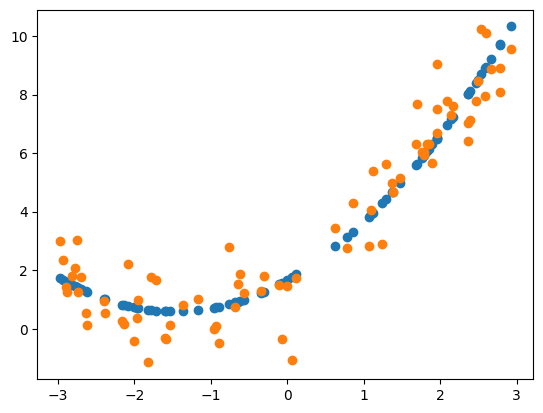

In [204]:
plt.scatter(x_train,regression.predict(x_train_poly))
plt.scatter(x_train,y_train)

In [205]:
poly=PolynomialFeatures(degree=3,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)



In [206]:
x_train_poly

array([[ 1.00000000e+00, -2.15780966e+00,  4.65614252e+00,
        -1.00470693e+01],
       [ 1.00000000e+00, -2.09082412e+00,  4.37154551e+00,
        -9.14013282e+00],
       [ 1.00000000e+00,  2.36613782e+00,  5.59860821e+00,
         1.32470786e+01],
       [ 1.00000000e+00,  2.36324896e+00,  5.58494567e+00,
         1.31986171e+01],
       [ 1.00000000e+00, -6.50568577e-01,  4.23239474e-01,
        -2.75346302e-01],
       [ 1.00000000e+00,  8.55357827e-01,  7.31637011e-01,
         6.25811444e-01],
       [ 1.00000000e+00,  6.29109313e-01,  3.95778528e-01,
         2.48987958e-01],
       [ 1.00000000e+00, -6.16137691e-01,  3.79625654e-01,
        -2.33901674e-01],
       [ 1.00000000e+00,  7.83734151e-01,  6.14239219e-01,
         4.81400253e-01],
       [ 1.00000000e+00, -6.55079987e-03,  4.29129789e-05,
        -2.81114336e-07],
       [ 1.00000000e+00, -3.42442014e-01,  1.17266533e-01,
        -4.01569879e-02],
       [ 1.00000000e+00, -2.37952920e+00,  5.66215920e+00,
      

In [207]:
# poor score compared to degree 2 
# therefore keep degree as 2 only 
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_poly,y_train)
y_pred=regression.predict(x_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8086010778919535


In [208]:
# prediction of my new dataset
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
x_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

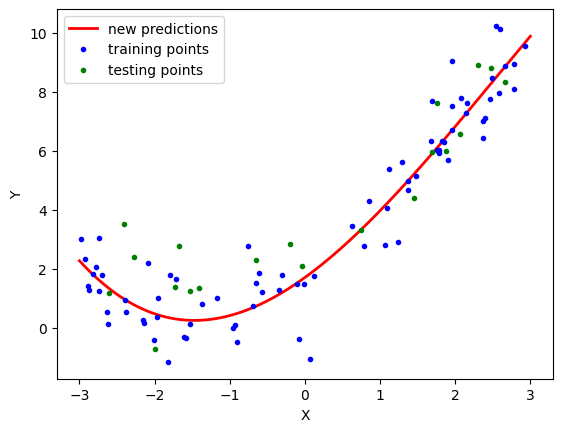

In [209]:
y_new=regression.predict(x_new_poly)
plt.plot(x_new,y_new,'r-',linewidth=2,label='new predictions')
plt.plot(x_train,y_train,'b.',label='training points')
plt.plot(x_test,y_test,'g.',label='testing points')
plt.xlabel('X')
plt.ylabel("Y")
plt.legend()
plt.show()

In [210]:
# Pieline for Polynomial Linear Regression
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    x_new=np.linspace(-3,3,200).reshape(200,1)
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([('poly_features',poly_features),('lin_reg',lin_reg)])
    poly_regression.fit(x_train,y_train) # polynomial and fit of linear regression 
    y_pred_new=poly_regression.predict(x_new)
    # plotting prediction line
    plt.plot(x_new,y_pred_new,'r',label='Degree '+str(degree),linewidth=2)
    plt.plot(x_train,y_train,'b.',linewidth=3)
    plt.plot(x_test,y_test,'g.',linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis([-4,4,0,10])
    plt.show()

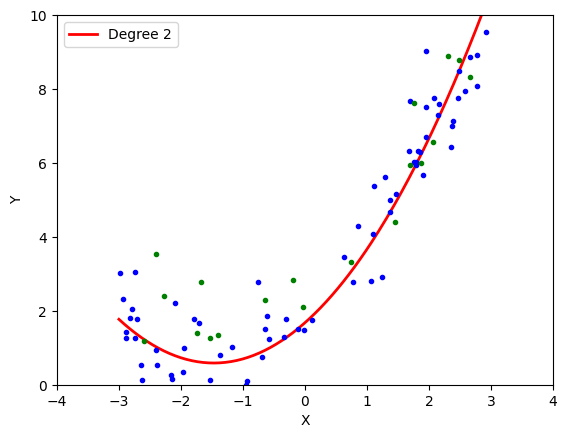

In [220]:
poly_regression(2)